# H2a bias-specific logistic regression analysis

This notebook estimates a separate effect for each bias type from one overall logistic regression fitted to all rows. Each bias type enters the model through its own signed active-side dummy variable:

$$\operatorname{logit}(P(y_i = 1)) = \alpha + \sum_{k} \beta_k X_{ik}$$

where:

- $y_i = 1$ means participant $i$ selected Side A.
- $k$ ranges over the four bias types: anchoring, fallacy, pro-jargon, and verbosity.
- $X_{ik} = +1$ when bias type $k$ is active on Side A.
- $X_{ik} = -1$ when bias type $k$ is active on Side B.
- $X_{ik} = 0$ otherwise, including every baseline row and every row that manipulates a different bias type.

All 369 rows share one intercept $\alpha$, the baseline effect. Baseline rows have every $X_{ik} = 0$ (all $\beta_k$ terms drop out), so for them the model reduces to $\operatorname{logit}(P(y_i = 1)) = \alpha$: $\alpha$ is the log-odds of choosing Side A from the story alone, with no active bias on either side. Each $\beta_k$ measures how strongly bias type $k$ pulls choices toward the side where it is active. Each bias type is tested with a one-degree-of-freedom likelihood-ratio test that drops only its $X_{ik}$ term from the overall model, and the four tests are Holm-adjusted.

## 1. Import packages

We use `pandas` to load and reshape the results file, `numpy` for simple coding, and `statsmodels` for the logistic regression. `scipy` supplies the chi-square p-values for the likelihood-ratio tests, and `IPython.display` lets us show the model outputs.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import Image, Markdown, display
from scipy.special import expit, logit
from scipy.stats import chi2
from statsmodels.stats.multitest import multipletests

## 2. Load the H2a results file

The notebook can be run either from the repository root or from the `results/` folder. The path check below supports both starting locations. `results.csv` is only read; it is not modified.

In [2]:
RESULTS_PATH = Path("results.csv")

if not RESULTS_PATH.exists():
    RESULTS_PATH = Path("results/results.csv")

# The participant's choice is stored as `adjudication`; the analysis calls it `selected_side`.
raw = pd.read_csv(RESULTS_PATH).rename(columns={"adjudication": "selected_side"})
raw.head()

,dialogue_id,dialogue_word_count,case,topic,bias_type,fallacy_subtype,variant_a,variant_b,ground_truth_side_order,dialogue_variant,selected_side,reward_type
0,1,717,our-quarterback-is-missing,Who was responsible for causing Eddie's disapp...,NaN,NaN,baseline,baseline,gt_first,primary-1,A,base_plus_incentive
1,1,717,our-quarterback-is-missing,Who was responsible for causing Eddie's disapp...,NaN,NaN,baseline,baseline,gt_first,primary-1,B,base_reward
2,1,717,our-quarterback-is-missing,Who was responsible for causing Eddie's disapp...,NaN,NaN,baseline,baseline,gt_first,primary-1,B,base_reward
3,1,717,our-quarterback-is-missing,Who was responsible for causing Eddie's disapp...,NaN,NaN,baseline,baseline,gt_first,primary-1,A,base_plus_incentive
4,1,717,our-quarterback-is-missing,Who was responsible for causing Eddie's disapp...,NaN,NaN,baseline,baseline,gt_first,primary-1,A,base_plus_incentive


## 3. Clean the analysis columns

The H2a analysis uses four fields:

- `bias_type`: the bias family for manipulated rows. Baseline rows are `N/A`, which pandas reads as missing.
- `variant_a`: whether Side A was `active` or `baseline`.
- `variant_b`: whether Side B was `active` or `baseline`.
- `selected_side`: which side the participant selected.

This cell standardizes text values and turns blank `bias_type` values into the explicit label `baseline`.

In [3]:
df = raw.copy()
df.columns = df.columns.str.strip()

df["variant_a"] = df["variant_a"].astype(str).str.strip().str.lower()
df["variant_b"] = df["variant_b"].astype(str).str.strip().str.lower()
df["selected_side"] = df["selected_side"].astype(str).str.strip().str.upper()

bias_type = df["bias_type"].where(df["bias_type"].notna(), "baseline")
df["bias_type_clean"] = bias_type.astype(str).str.strip().str.lower()
df["bias_type_clean"] = df["bias_type_clean"].replace({"": "baseline", "nan": "baseline"})

df = df.loc[df["selected_side"].isin(["A", "B"])].copy()
df.shape

(369, 13)

## 4. Code the outcome and the bias-specific active-side dummies

The outcome is `y`, where `1` means Side A was selected and `0` means Side B was selected.

`X` is the signed active-side indicator used in H1:

- `X = 0`: baseline row.
- `X = 1`: active bias appears on Side A.
- `X = -1`: active bias appears on Side B.

The overall H2a model splits `X` into one signed dummy per bias type. `X_<bias_type>` equals `X` on that bias type's rows and `0` on every other row, so baseline rows are `0` on all four dummies. A positive coefficient on `X_<bias_type>` means that bias type moves choices toward the side where it is active.

In [4]:
a_active = df["variant_a"].eq("active") & df["variant_b"].eq("baseline")
b_active = df["variant_a"].eq("baseline") & df["variant_b"].eq("active")
baseline = df["variant_a"].eq("baseline") & df["variant_b"].eq("baseline")

df["is_baseline"] = baseline
df["active_side"] = np.select(
    [a_active, b_active, baseline],
    ["A", "B", "baseline"],
    default="unexpected",
)

df["X"] = np.select(
    [df["active_side"].eq("A"), df["active_side"].eq("B")],
    [1, -1],
    default=0,
).astype(int)

df["y"] = df["selected_side"].eq("A").astype(int)

BIAS_LABELS = {
    "anchoring_bias": "anchoring",
    "fallacy_trait": "fallacy",
    "pro_jargon_bias": "pro-jargon",
    "verbosity_bias": "verbosity",
}

df["bias_label"] = df["bias_type_clean"].map(BIAS_LABELS).fillna(df["bias_type_clean"])

# One signed active-side dummy per bias type: X on that bias type's rows, 0 everywhere else.
BIAS_TERMS = {bias_type: f"X_{bias_type}" for bias_type in BIAS_LABELS}
for bias_type, term in BIAS_TERMS.items():
    df[term] = df["X"].where(df["bias_type_clean"].eq(bias_type), 0).astype(int)

df[["bias_type_clean", "bias_label", "variant_a", "variant_b", "selected_side", "active_side", "X", *BIAS_TERMS.values(), "y"]].head(12)

,bias_type_clean,bias_label,variant_a,variant_b,selected_side,active_side,X,X_anchoring_bias,X_fallacy_trait,X_pro_jargon_bias,X_verbosity_bias,y
0,baseline,baseline,baseline,baseline,A,baseline,0,0,0,0,0,1
1,baseline,baseline,baseline,baseline,B,baseline,0,0,0,0,0,0
2,baseline,baseline,baseline,baseline,B,baseline,0,0,0,0,0,0
3,baseline,baseline,baseline,baseline,A,baseline,0,0,0,0,0,1
4,baseline,baseline,baseline,baseline,A,baseline,0,0,0,0,0,1
5,baseline,baseline,baseline,baseline,A,baseline,0,0,0,0,0,1
6,baseline,baseline,baseline,baseline,A,baseline,0,0,0,0,0,1
7,baseline,baseline,baseline,baseline,A,baseline,0,0,0,0,0,1
8,baseline,baseline,baseline,baseline,B,baseline,0,0,0,0,0,0
9,baseline,baseline,baseline,baseline,A,baseline,0,0,0,0,0,1


## 5. Check that the coding matches the H2a design

The overall model assumes that baseline rows have blank/baseline `bias_type`, and manipulated rows have one of the four bias labels. These checks stop the notebook if any row does not fit that structure.

In [5]:
assert not df["active_side"].eq("unexpected").any(), "Some rows do not match the expected active/baseline design."
assert df.loc[df["is_baseline"], "bias_type_clean"].eq("baseline").all(), "A baseline row has a non-baseline bias_type."
assert not df.loc[~df["is_baseline"], "bias_type_clean"].eq("baseline").any(), "A manipulated row is missing bias_type."

pd.crosstab([df["bias_label"], df["active_side"]], df["selected_side"], margins=True)

selected_side             A    B  All
bias_label active_side               
anchoring  A             24   14   38
           B             16   20   36
baseline   baseline      51   21   72
fallacy    A             25   11   36
           B             22   18   40
pro-jargon A             27   11   38
           B             21   16   37
verbosity  A             23   13   36
           B             15   21   36
All                     224  145  369

## 6. Identify the four bias types to test

This list excludes baseline rows. Each item in `BIAS_TYPES` gets its own signed dummy, and so its own coefficient, in the one overall model. `MODEL_TERMS` keeps the four dummies in the same order as `BIAS_TYPES`.

In [6]:
BIAS_TYPES = [
    "anchoring_bias",
    "fallacy_trait",
    "pro_jargon_bias",
    "verbosity_bias",
]

MODEL_TERMS = [BIAS_TERMS[bias_type] for bias_type in BIAS_TYPES]

bias_counts = (
    df.loc[~df["is_baseline"]]
    .groupby(["bias_type_clean", "bias_label", "active_side"])
    .size()
    .rename("n")
    .reset_index()
)

bias_counts

,bias_type_clean,bias_label,active_side,n
0,anchoring_bias,anchoring,A,38
1,anchoring_bias,anchoring,B,36
2,fallacy_trait,fallacy,A,36
3,fallacy_trait,fallacy,B,40
4,pro_jargon_bias,pro-jargon,A,38
5,pro_jargon_bias,pro-jargon,B,37
6,verbosity_bias,verbosity,A,36
7,verbosity_bias,verbosity,B,36


## 7. Define the overall bias-specific model

The function below runs the whole H2a analysis on one dataframe:

1. Fit `logit(P(y = 1)) = alpha + sum_k beta_k X_k` to all rows.
2. For each bias type, compare the overall model to the same model without that bias type's dummy with a one-degree-of-freedom likelihood-ratio test. The other three dummies stay in both models.
3. Convert each coefficient into an odds ratio and model-implied probabilities.

Every bias type shares the same intercept `alpha`, the baseline effect (the model's prediction when every `X_k = 0`), so all four effects are measured against the same baseline.

In [7]:
def probability_shift(alpha, beta):
    return 0.5 * (expit(alpha + beta) - expit(alpha - beta))


def fit_bias_specific_model(data):
    X_model = sm.add_constant(data[MODEL_TERMS], has_constant="add")
    model = sm.Logit(data["y"], X_model).fit(disp=False)

    coef_table = pd.DataFrame(
        {
            "log_odds": model.params,
            "odds_ratio": np.exp(model.params),
            "ci_low_odds_ratio": np.exp(model.conf_int()[0]),
            "ci_high_odds_ratio": np.exp(model.conf_int()[1]),
            "p_value": model.pvalues,
        }
    )

    lrt_rows = []
    for bias_type in BIAS_TYPES:
        term = BIAS_TERMS[bias_type]
        reduced_model = sm.Logit(data["y"], X_model.drop(columns=term)).fit(disp=False)
        lr_stat = 2 * (model.llf - reduced_model.llf)
        lrt_rows.append(
            {
                "bias_type": BIAS_LABELS[bias_type],
                "comparison": f"overall model vs overall model without {term}",
                "lr_statistic": lr_stat,
                "df": 1,
                "p_value": chi2.sf(lr_stat, df=1),
            }
        )
    lrt_table = pd.DataFrame(lrt_rows)

    grid_rows = [{"bias_type": "baseline", "condition": "baseline", "const": 1, **dict.fromkeys(MODEL_TERMS, 0)}]
    for bias_type in BIAS_TYPES:
        for condition, sign in [("active on Side A", 1), ("active on Side B", -1)]:
            row = {"bias_type": BIAS_LABELS[bias_type], "condition": condition, "const": 1, **dict.fromkeys(MODEL_TERMS, 0)}
            row[BIAS_TERMS[bias_type]] = sign
            grid_rows.append(row)

    prediction_grid = pd.DataFrame(grid_rows)
    prediction_grid["predicted_probability_choose_A"] = model.predict(prediction_grid[["const", *MODEL_TERMS]])

    predictions = prediction_grid.set_index(["bias_type", "condition"])["predicted_probability_choose_A"]
    effect_table = pd.DataFrame(
        {
            "bias_type": [BIAS_LABELS[bias_type] for bias_type in BIAS_TYPES],
            "predicted_baseline_choose_A": predictions[("baseline", "baseline")],
            "predicted_active_A_choose_A": [predictions[(BIAS_LABELS[b], "active on Side A")] for b in BIAS_TYPES],
            "predicted_active_B_choose_A": [predictions[(BIAS_LABELS[b], "active on Side B")] for b in BIAS_TYPES],
        }
    )
    effect_table["effect_toward_active_side"] = 0.5 * (
        effect_table["predicted_active_A_choose_A"] - effect_table["predicted_active_B_choose_A"]
    )

    return {
        "model": model,
        "coef_table": coef_table,
        "lrt_table": lrt_table,
        "prediction_grid": prediction_grid,
        "effect_table": effect_table,
    }

## 8. Fit the overall model

This cell fits the model once on all rows. The result dictionary stores the fitted model and tables for later display, and the table below shows the model-implied effect for each bias type.

In [8]:
result = fit_bias_specific_model(df)

result["effect_table"]

,bias_type,predicted_baseline_choose_A,predicted_active_A_choose_A,predicted_active_B_choose_A,effect_toward_active_side
0,anchoring,0.609989,0.697833,0.514379,0.091727
1,fallacy,0.609989,0.679085,0.536177,0.071454
2,pro-jargon,0.609989,0.679500,0.535703,0.071899
3,verbosity,0.609989,0.715407,0.493185,0.111111


## 9. Bootstrap confidence intervals for bias-specific effects

Each reported H2a effect is a probability-point shift toward the active side, so the confidence interval should be on that same scale. Because the four effects come from one model, each bootstrap iteration resamples all rows with replacement, refits the overall model, and recomputes all four probability-shift statistics. The CI for each bias type is the 2.5th and 97.5th percentile of its bootstrap distribution.

The bootstrap refits use a grouped Newton-Raphson logistic fit, which is much faster than building 10,000 `statsmodels` result objects. The cell first checks that it reproduces the `statsmodels` point estimates.

In [9]:
N_BOOTSTRAP = 10000
BOOTSTRAP_SEED = 20260902
BOOTSTRAP_WARN_THRESHOLD = 0.90


def group_rows(y_values, design):
    # Rows with identical design values share a fitted probability, so they can be fitted as one binomial cell.
    cells, cell_index = np.unique(np.asarray(design, dtype=float), axis=0, return_inverse=True)
    cell_index = cell_index.ravel()
    totals = np.bincount(cell_index, minlength=len(cells)).astype(float)
    successes = np.bincount(cell_index, weights=np.asarray(y_values, dtype=float), minlength=len(cells))
    return successes, totals, cells


def grouped_logit_fit(successes, totals, design):
    overall_rate = successes.sum() / totals.sum()
    if overall_rate <= 0 or overall_rate >= 1:
        raise RuntimeError("Sample has complete outcome separation.")

    params = np.zeros(design.shape[1])
    params[0] = logit(overall_rate)
    for _ in range(50):
        p = expit(design @ params)
        score = design.T @ (successes - totals * p)
        info = design.T @ (design * (totals * p * (1 - p))[:, None])
        step = np.linalg.solve(info, score)
        params += step
        if np.max(np.abs(step)) < 1e-10:
            break
    else:
        raise RuntimeError("Logistic fit did not converge.")

    if not np.all(np.isfinite(params)):
        raise RuntimeError("Logistic fit returned non-finite parameters.")

    eta = design @ params
    log_likelihood = float(np.sum(successes * -np.logaddexp(0, -eta) + (totals - successes) * -np.logaddexp(0, eta)))
    return params, log_likelihood


def model_design(data):
    return np.column_stack([np.ones(len(data)), data[MODEL_TERMS].to_numpy(dtype=float)])


def bias_specific_effects(data):
    params, _ = grouped_logit_fit(*group_rows(data["y"].to_numpy(), model_design(data)))
    return probability_shift(params[0], params[1:])


def bootstrap_effect_ci(data, effect_fn, n_boot=N_BOOTSTRAP, seed=BOOTSTRAP_SEED):
    rng = np.random.default_rng(seed)
    effects = []
    n = len(data)

    for _ in range(n_boot):
        sample_positions = rng.integers(0, n, size=n)
        sample = data.iloc[sample_positions]
        try:
            effects.append(effect_fn(sample))
        except Exception:
            continue

    effects = np.asarray(effects, dtype=float)
    if len(effects) == 0:
        raise RuntimeError("All bootstrap fits failed.")
    if len(effects) < BOOTSTRAP_WARN_THRESHOLD * n_boot:
        warnings.warn(
            f"Only {len(effects)} of {n_boot} bootstrap fits succeeded.",
            RuntimeWarning,
        )

    return {
        "estimate": effect_fn(data),
        "ci_low": np.percentile(effects, 2.5, axis=0),
        "ci_high": np.percentile(effects, 97.5, axis=0),
        "n_success": len(effects),
        "n_failed": n_boot - len(effects),
    }


notebook_effects = result["effect_table"]["effect_toward_active_side"].to_numpy()
effect_check = bias_specific_effects(df)
if not np.allclose(effect_check, notebook_effects, atol=5e-7):
    raise AssertionError(
        f"Bootstrap effect function does not match the notebook point estimates: {effect_check} vs {notebook_effects}"
    )

bootstrap_result = bootstrap_effect_ci(df, bias_specific_effects)

pd.DataFrame(
    {
        "bias_type": [BIAS_LABELS[bias_type] for bias_type in BIAS_TYPES],
        "effect_pp": 100 * bootstrap_result["estimate"],
        "ci_low_pp": 100 * bootstrap_result["ci_low"],
        "ci_high_pp": 100 * bootstrap_result["ci_high"],
        "bootstrap_successes": bootstrap_result["n_success"],
        "bootstrap_failures": bootstrap_result["n_failed"],
    }
)

,bias_type,effect_pp,ci_low_pp,ci_high_pp,bootstrap_successes,bootstrap_failures
0,anchoring,9.172686,-2.407258,20.391304,10000,0
1,fallacy,7.145427,-3.878794,17.961750,10000,0
2,pro-jargon,7.189864,-3.867872,17.821768,10000,0
3,verbosity,11.111111,-0.809997,22.296909,10000,0


## 10. Summary table across bias types

This compact table is the easiest place to compare the four bias types. The key coefficient for each bias type is its `X_<bias_type>` dummy in the overall model. Every row comes from the same model, so `n_model` and `n_baseline` are shared.

A positive `beta_log_odds` means the active bias pulls choices toward the side where it is active. The `effect_pp` and bootstrap CI columns report the same effect on the percentage-point scale. The `lrt_p_value` tests whether that bias type's dummy improves fit compared with the overall model without it. The `holm_p_value` column adjusts the four LRT p-values for testing four bias types.

In [10]:
summary_rows = []
coef_table = result["coef_table"]
lrt_table = result["lrt_table"].set_index("bias_type")
effect_table = result["effect_table"].set_index("bias_type")

for i, bias_type in enumerate(BIAS_TYPES):
    label = BIAS_LABELS[bias_type]
    coef = coef_table.loc[BIAS_TERMS[bias_type]]
    lrt = lrt_table.loc[label]
    effect = effect_table.loc[label]
    bias_rows = df["bias_type_clean"].eq(bias_type)

    summary_rows.append(
        {
            "bias_type": label,
            "n_model": len(df),
            "n_baseline": int(df["is_baseline"].sum()),
            "n_active_side_a": int((bias_rows & df["active_side"].eq("A")).sum()),
            "n_active_side_b": int((bias_rows & df["active_side"].eq("B")).sum()),
            "beta_log_odds": coef["log_odds"],
            "odds_ratio": coef["odds_ratio"],
            "ci_low_odds_ratio": coef["ci_low_odds_ratio"],
            "ci_high_odds_ratio": coef["ci_high_odds_ratio"],
            "wald_p_value": coef["p_value"],
            "lrt_statistic": lrt["lr_statistic"],
            "lrt_p_value": lrt["p_value"],
            "predicted_baseline_choose_A": effect["predicted_baseline_choose_A"],
            "predicted_active_A_choose_A": effect["predicted_active_A_choose_A"],
            "predicted_active_B_choose_A": effect["predicted_active_B_choose_A"],
            "effect_toward_active_side": effect["effect_toward_active_side"],
            "effect_pp": 100 * effect["effect_toward_active_side"],
            "effect_ci_low_pp": 100 * bootstrap_result["ci_low"][i],
            "effect_ci_high_pp": 100 * bootstrap_result["ci_high"][i],
            "bootstrap_successes": bootstrap_result["n_success"],
            "bootstrap_failures": bootstrap_result["n_failed"],
        }
    )

summary = pd.DataFrame(summary_rows)
summary["holm_p_value"] = multipletests(summary["lrt_p_value"], method="holm")[1]
summary["significant_holm_0_05"] = summary["holm_p_value"] < 0.05

summary

,bias_type,n_model,n_baseline,n_active_side_a,n_active_side_b,beta_log_odds,odds_ratio,ci_low_odds_ratio,ci_high_odds_ratio,wald_p_value,...,predicted_active_A_choose_A,predicted_active_B_choose_A,effect_toward_active_side,effect_pp,effect_ci_low_pp,effect_ci_high_pp,bootstrap_successes,bootstrap_failures,holm_p_value,significant_holm_0_05
0,anchoring,369,72,38,36,0.389733,1.476587,0.917860,2.375428,0.108135,...,0.697833,0.514379,0.091727,9.172686,-2.407258,20.391304,10000,0,0.315172,False
1,fallacy,369,72,36,40,0.302306,1.352975,0.849576,2.154651,0.202902,...,0.679085,0.536177,0.071454,7.145427,-3.878794,17.961750,10000,0,0.401305,False
2,pro-jargon,369,72,38,37,0.304210,1.355554,0.848119,2.166592,0.203567,...,0.679500,0.535703,0.071899,7.189864,-3.867872,17.821768,10000,0,0.401305,False
3,verbosity,369,72,36,36,0.474527,1.607254,0.989057,2.611848,0.055423,...,0.715407,0.493185,0.111111,11.111111,-0.809997,22.296909,10000,0,0.209464,False


## 11. Holm correction across the four bias-specific tests

Because we test four bias types, this cell reports the raw LRT p-value and the Holm-adjusted p-value side by side. Holm adjustment controls the family-wise error rate across the four drop-one tests while preserving the raw p-values for transparency.

In [11]:
holm_table = summary[[
    "bias_type",
    "lrt_p_value",
    "holm_p_value",
    "significant_holm_0_05",
]]

holm_table

,bias_type,lrt_p_value,holm_p_value,significant_holm_0_05
0,anchoring,0.105057,0.315172,False
1,fallacy,0.200652,0.401305,False
2,pro-jargon,0.201160,0.401305,False
3,verbosity,0.052366,0.209464,False


## 12. Publication-ready H2a effect table

This table reports the bias-specific effects from the overall model and their 95% bootstrap CIs on the same percentage-point scale as the effect size, together with the drop-one LRT and multiplicity-corrected p-values.

In [12]:
h2a_publication_table = pd.DataFrame(
    {
        "Bias": summary["bias_type"],
        "Effect (pp)": summary["effect_pp"].map(lambda value: f"{value:+.1f}"),
        "95% bootstrap CI (pp)": [
            f"[{low:+.1f}, {high:+.1f}]"
            for low, high in zip(summary["effect_ci_low_pp"], summary["effect_ci_high_pp"])
        ],
        "LRT statistic": summary["lrt_statistic"],
        "Raw p": summary["lrt_p_value"],
        "Holm p": summary["holm_p_value"],
    }
)

for _, row in h2a_publication_table.iterrows():
    print(
        f"{row['Bias']}: {row['Effect (pp)']} pp "
        f"(95% bootstrap CI {row['95% bootstrap CI (pp)']} pp), "
        f"LRT={row['LRT statistic']:.3f}, raw p={row['Raw p']:.6f}, Holm p={row['Holm p']:.6f}"
    )

h2a_publication_table

anchoring: +9.2 pp (95% bootstrap CI [-2.4, +20.4] pp), LRT=2.627, raw p=0.105057, Holm p=0.315172
fallacy: +7.1 pp (95% bootstrap CI [-3.9, +18.0] pp), LRT=1.638, raw p=0.200652, Holm p=0.401305
pro-jargon: +7.2 pp (95% bootstrap CI [-3.9, +17.8] pp), LRT=1.634, raw p=0.201160, Holm p=0.401305
verbosity: +11.1 pp (95% bootstrap CI [-0.8, +22.3] pp), LRT=3.764, raw p=0.052366, Holm p=0.209464


,Bias,Effect (pp),95% bootstrap CI (pp),LRT statistic,Raw p,Holm p
0,anchoring,+9.2,"[-2.4, +20.4]",2.627041,0.105057,0.315172
1,fallacy,+7.1,"[-3.9, +18.0]",1.637619,0.200652,0.401305
2,pro-jargon,+7.2,"[-3.9, +17.8]",1.633932,0.201160,0.401305
3,verbosity,+11.1,"[-0.8, +22.3]",3.764034,0.052366,0.209464


## 13. Descriptive rates by bias type and active side

These are raw observed rates, not model estimates. The baseline row is shared by all four bias types in the overall model. This helps check whether the regression direction matches the observed Side A selection rates.

In [13]:
descriptive_order = [("baseline", "baseline")] + [
    (BIAS_LABELS[bias_type], side) for bias_type in BIAS_TYPES for side in ("A", "B")
]

(
    df.groupby(["bias_label", "active_side"])
    .agg(n=("y", "size"), side_a_rate=("y", "mean"))
    .reindex(pd.MultiIndex.from_tuples(descriptive_order, names=["bias_label", "active_side"]))
)

n  side_a_rate
bias_label active_side                 
baseline   baseline     72     0.708333
anchoring  A            38     0.631579
           B            36     0.444444
fallacy    A            36     0.694444
           B            40     0.550000
pro-jargon A            38     0.710526
           B            37     0.567568
verbosity  A            36     0.638889
           B            36     0.416667

## 14. Full regression output

The next cell prints the detailed `statsmodels` result for the overall model, followed by the easier-to-read coefficient table, the four drop-one likelihood-ratio tests, the model-implied probabilities, and the model-implied effects.

In [14]:
display(result["model"].summary())
display(Markdown("Coefficient table"))
display(result["coef_table"])
display(Markdown("Drop-one likelihood-ratio tests"))
display(result["lrt_table"])
display(Markdown("Model-implied probabilities"))
display(result["prediction_grid"])
display(Markdown("Model-implied effects toward the active side"))
display(result["effect_table"])

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:                  369
Model:                          Logit   Df Residuals:                      364
Method:                           MLE   Df Model:                            4
Date:                Fri, 25 Sep 2026   Pseudo R-squ.:                 0.01952
Time:                        18:22:02   Log-Likelihood:                -242.42
converged:                       True   LL-Null:                       -247.25
Covariance Type:            nonrobust   LLR p-value:                   0.04668
=====================================================================================
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.4473      0.108      4.129      0.000       0.235       0.660
X_anchoring_bias      0.3897      0.243      1.607      0.108      -0.086       0.865
X_fallacy_trait       0.3023      0.237      1.273      0.203      -0.163       0.768
X_pro_jargon_bias     0.3042      0.239      1.271      0.204      -0.165       0.773
X_verbosity_bias      0.4745      0.248      1.916      0.055      -0.011       0.960
=====================================================================================
"""

Coefficient table

,log_odds,odds_ratio,ci_low_odds_ratio,ci_high_odds_ratio,p_value
const,0.447266,1.564030,1.264832,1.934005,0.000036
X_anchoring_bias,0.389733,1.476587,0.917860,2.375428,0.108135
X_fallacy_trait,0.302306,1.352975,0.849576,2.154651,0.202902
X_pro_jargon_bias,0.304210,1.355554,0.848119,2.166592,0.203567
X_verbosity_bias,0.474527,1.607254,0.989057,2.611848,0.055423


Drop-one likelihood-ratio tests

,bias_type,comparison,lr_statistic,df,p_value
0,anchoring,overall model vs overall model without X_ancho...,2.627041,1,0.105057
1,fallacy,overall model vs overall model without X_falla...,1.637619,1,0.200652
2,pro-jargon,overall model vs overall model without X_pro_j...,1.633932,1,0.201160
3,verbosity,overall model vs overall model without X_verbo...,3.764034,1,0.052366


Model-implied probabilities

,bias_type,condition,const,X_anchoring_bias,X_fallacy_trait,X_pro_jargon_bias,X_verbosity_bias,predicted_probability_choose_A
0,baseline,baseline,1,0,0,0,0,0.609989
1,anchoring,active on Side A,1,1,0,0,0,0.697833
2,anchoring,active on Side B,1,-1,0,0,0,0.514379
3,fallacy,active on Side A,1,0,1,0,0,0.679085
4,fallacy,active on Side B,1,0,-1,0,0,0.536177
5,pro-jargon,active on Side A,1,0,0,1,0,0.679500
6,pro-jargon,active on Side B,1,0,0,-1,0,0.535703
7,verbosity,active on Side A,1,0,0,0,1,0.715407
8,verbosity,active on Side B,1,0,0,0,-1,0.493185


Model-implied effects toward the active side

,bias_type,predicted_baseline_choose_A,predicted_active_A_choose_A,predicted_active_B_choose_A,effect_toward_active_side
0,anchoring,0.609989,0.697833,0.514379,0.091727
1,fallacy,0.609989,0.679085,0.536177,0.071454
2,pro-jargon,0.609989,0.679500,0.535703,0.071899
3,verbosity,0.609989,0.715407,0.493185,0.111111


## 15. Power/sensitivity analysis

This section estimates the detection power of the current notebook models under common true bias effects from 2 to 20 percentage points. The simulation keeps the same row-level design structure as the observed H2a dataset.

For each simulated dataset, we run the current aggregate H1 likelihood-ratio test on all rows, then run the four drop-one H2a likelihood-ratio tests from the overall bias-specific model before and after Holm correction.

In [15]:
from scipy.optimize import brentq

POWER_EFFECT_PPS = np.arange(2.0, 22.0, 2.0)
N_POWER_SIMULATIONS = 500
POWER_ALPHA = 0.05
POWER_SEED = 20260902

POWER_BIAS_KEYS = {
    "anchoring_bias": "anchoring",
    "fallacy_trait": "fallacy",
    "pro_jargon_bias": "pro_jargon",
    "verbosity_bias": "verbosity",
}

POWER_OUTPUT_DIR = RESULTS_PATH.parent
POWER_CURVE_CSV = POWER_OUTPUT_DIR / "power_curve.csv"
POWER_CURVE_PNG = POWER_OUTPUT_DIR / "power_curve.png"

## 16. Power simulation helpers

The helper functions below use the same likelihood-ratio logic as the current notebook models. The simulation reuses the grouped logistic fit from the bootstrap: every model here has only indicator-style predictors, so rows collapse into the nine experimental cells (baseline plus four bias types on each side). Fitting on those cells gives the same likelihood-ratio tests much faster than refitting thousands of full `statsmodels` result objects.

In [16]:
def beta_for_probability_shift(alpha, target_shift):
    if target_shift <= 0:
        return 0.0

    upper = 1.0
    while probability_shift(alpha, upper) < target_shift:
        upper *= 2.0
        if upper > 50:
            raise ValueError("Could not bracket beta for the requested probability shift.")

    return brentq(lambda beta: probability_shift(alpha, beta) - target_shift, 0.0, upper)


def grouped_lrt_p_value(y_values, full_design, reduced_design):
    _, ll_full = grouped_logit_fit(*group_rows(y_values, full_design))
    _, ll_reduced = grouped_logit_fit(*group_rows(y_values, reduced_design))

    lr_stat = max(0.0, 2.0 * (ll_full - ll_reduced))
    df_diff = full_design.shape[1] - reduced_design.shape[1]
    return float(chi2.sf(lr_stat, df=df_diff))


def holm_adjust_four(p_values):
    p_values = np.asarray(p_values, dtype=float)
    adjusted = np.empty_like(p_values)
    order = np.argsort(p_values)
    running_max = 0.0
    m = len(p_values)

    for rank, idx in enumerate(order):
        running_max = max(running_max, (m - rank) * p_values[idx])
        adjusted[idx] = min(running_max, 1.0)

    return adjusted


def current_h1_model_and_null():
    X_full = sm.add_constant(df[["X"]], has_constant="add")
    full = sm.Logit(df["y"], X_full).fit(disp=False)

    X_null = pd.DataFrame({"const": 1}, index=df.index)
    null = sm.Logit(df["y"], X_null).fit(disp=False)

    lr_stat = 2 * (full.llf - null.llf)
    p_value = chi2.sf(lr_stat, df=1)
    observed_effect = probability_shift(full.params["const"], full.params["X"])
    return full, null, float(p_value), float(observed_effect)


def simulate_power_curve(effect_pps=POWER_EFFECT_PPS, n_sim=N_POWER_SIMULATIONS, seed=POWER_SEED):
    h1_full, h1_null, h1_observed_p, observed_overall_effect = current_h1_model_and_null()
    baseline_alpha = float(h1_null.params["const"])
    row_x = df["X"].to_numpy(dtype=float)
    rng = np.random.default_rng(seed)

    null_design = np.ones((len(df), 1))
    h1_design = np.column_stack([np.ones(len(df)), row_x])
    h2a_design = model_design(df)
    # Column 0 is the intercept; column i + 1 is the dummy for BIAS_TYPES[i].
    h2a_reduced_designs = [np.delete(h2a_design, i + 1, axis=1) for i in range(len(BIAS_TYPES))]

    rows = []
    for effect_pp in effect_pps:
        target_shift = effect_pp / 100.0
        beta = beta_for_probability_shift(baseline_alpha, target_shift)
        true_p = expit(baseline_alpha + beta * row_x)

        h1_hits = 0
        raw_hits = {bias_type: 0 for bias_type in BIAS_TYPES}
        holm_hits = {bias_type: 0 for bias_type in BIAS_TYPES}
        failed = 0

        for _ in range(n_sim):
            y_sim = rng.binomial(1, true_p)

            try:
                h1_p = grouped_lrt_p_value(y_sim, h1_design, null_design)
                raw_p_values = [
                    grouped_lrt_p_value(y_sim, h2a_design, reduced_design)
                    for reduced_design in h2a_reduced_designs
                ]
                holm_p_values = holm_adjust_four(raw_p_values)
            except Exception:
                failed += 1
                continue

            h1_hits += int(h1_p < POWER_ALPHA)
            for bias_type, raw_p, holm_p in zip(BIAS_TYPES, raw_p_values, holm_p_values):
                raw_hits[bias_type] += int(raw_p < POWER_ALPHA)
                holm_hits[bias_type] += int(holm_p < POWER_ALPHA)

        success = n_sim - failed
        row = {
            "true_effect_pp": float(effect_pp),
            "true_beta": float(beta),
            "h1_overall_power": h1_hits / success if success else np.nan,
            "omnibus_power": h1_hits / success if success else np.nan,
            "n_success": int(success),
            "n_failed": int(failed),
        }

        for bias_type in BIAS_TYPES:
            key = POWER_BIAS_KEYS[bias_type]
            row[f"raw_power_{key}"] = raw_hits[bias_type] / success if success else np.nan
            row[f"holm_power_{key}"] = holm_hits[bias_type] / success if success else np.nan

        rows.append(row)

    observed_bias_effects = {
        row["bias_type"].replace("-", "_"): float(row["effect_toward_active_side"])
        for _, row in summary.iterrows()
    }

    return pd.DataFrame(rows), observed_bias_effects, observed_overall_effect

## 17. Run the power simulation and save the CSV

This cell simulates common true effects from 2 to 20 percentage points, estimates power for the current H1 and H2a tests, and saves the reusable simulation table to `power_curve.csv` in the same folder as `results.csv`.

In [17]:
power_table, observed_bias_effects, observed_overall_effect = simulate_power_curve()

POWER_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
power_table.to_csv(POWER_CURVE_CSV, index=False)

power_table

,true_effect_pp,true_beta,h1_overall_power,omnibus_power,n_success,n_failed,raw_power_anchoring,holm_power_anchoring,raw_power_fallacy,holm_power_fallacy,raw_power_pro_jargon,holm_power_pro_jargon,raw_power_verbosity,holm_power_verbosity
0,2.0,0.083885,0.122,0.122,500,0,0.076,0.022,0.080,0.030,0.090,0.022,0.058,0.014
1,4.0,0.168026,0.270,0.270,500,0,0.096,0.048,0.102,0.030,0.122,0.026,0.092,0.034
2,6.0,0.252683,0.564,0.564,500,0,0.158,0.064,0.188,0.066,0.256,0.106,0.160,0.078
3,8.0,0.338126,0.798,0.798,500,0,0.298,0.154,0.336,0.184,0.348,0.168,0.270,0.150
4,10.0,0.424642,0.948,0.948,500,0,0.406,0.266,0.440,0.270,0.492,0.286,0.378,0.232
5,12.0,0.512541,0.984,0.984,500,0,0.546,0.412,0.584,0.438,0.602,0.398,0.552,0.412
6,14.0,0.602161,0.998,0.998,500,0,0.698,0.570,0.738,0.616,0.692,0.562,0.666,0.564
7,16.0,0.693884,1.000,1.000,500,0,0.814,0.766,0.828,0.776,0.854,0.778,0.808,0.742
8,18.0,0.788139,1.000,1.000,500,0,0.918,0.882,0.938,0.908,0.918,0.874,0.864,0.836
9,20.0,0.885428,1.000,1.000,500,0,0.956,0.950,0.956,0.950,0.974,0.964,0.956,0.950


## 18. Plot the compact power curve

This cell saves the figure to `power_curve.png` in the same folder as `results.csv` and shows it below. Blue is H1 overall power, orange is raw H2a tests, green is Holm-adjusted H2a tests, and gray marks the observed effects and the 80% power line.

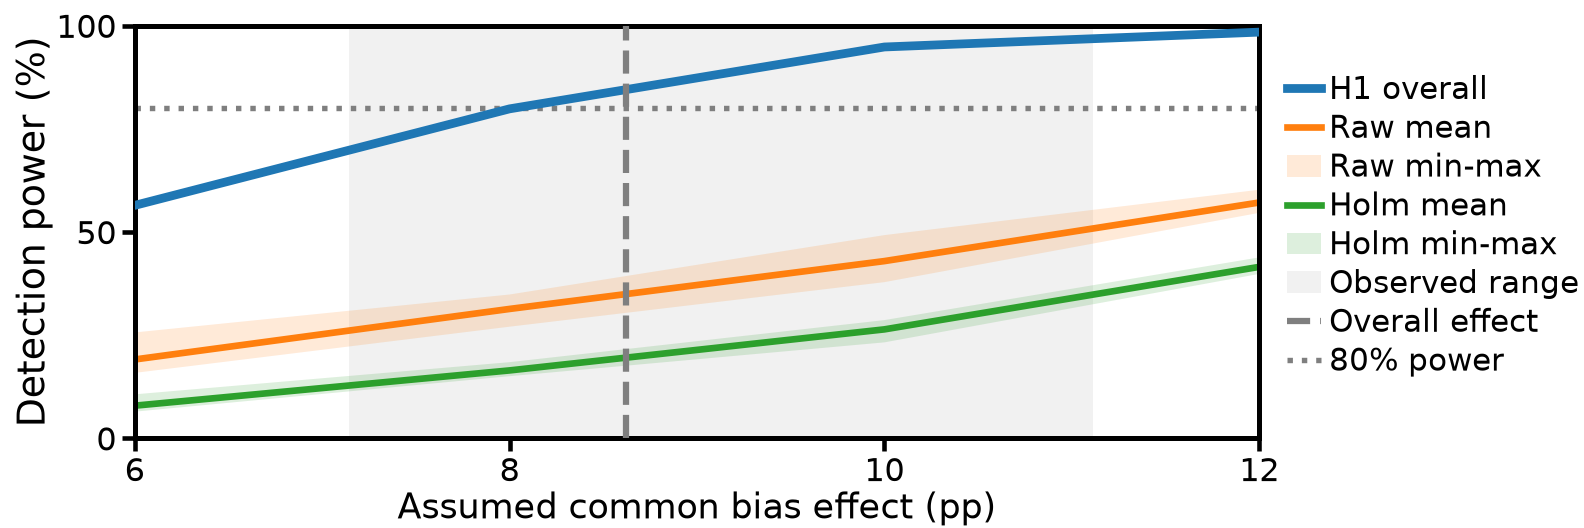

In [18]:
def power_band(table, columns):
    arr = table.loc[:, list(columns)].to_numpy(dtype=float)
    return 100.0 * np.nanmin(arr, axis=1), 100.0 * np.nanmax(arr, axis=1)


def write_current_power_curve_plot(table, output_path, observed_deltas, observed_overall):
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch

    width_pt = 190.79652
    height_pt = 63.70892
    tex_pt_per_inch = 72.27
    dpi = 600

    h1_color = "#1f77b4"
    raw_color = "#ff7f0e"
    holm_color = "#2ca02c"
    ref_color = "#7f7f7f"

    x = table["true_effect_pp"].to_numpy(dtype=float)
    h1_power = 100.0 * table["h1_overall_power"].to_numpy(dtype=float)

    bias_keys = list(POWER_BIAS_KEYS.values())
    raw_cols = [f"raw_power_{key}" for key in bias_keys]
    holm_cols = [f"holm_power_{key}" for key in bias_keys]
    raw_lo, raw_hi = power_band(table, raw_cols)
    holm_lo, holm_hi = power_band(table, holm_cols)
    raw_mean = 100.0 * table[raw_cols].mean(axis=1).to_numpy(dtype=float)
    holm_mean = 100.0 * table[holm_cols].mean(axis=1).to_numpy(dtype=float)

    observed_pp = [100.0 * value for value in observed_deltas.values()]
    overall_pp = 100.0 * observed_overall
    anchors = observed_pp + [overall_pp]
    center = 0.5 * (min(anchors) + max(anchors))
    half_width = max(0.5 * (max(anchors) - min(anchors)) + 1.5, 2.5)
    x_min = max(float(np.min(x)), center - half_width)
    x_max = min(float(np.max(x)), center + half_width)
    mask = (x >= x_min) & (x <= x_max)
    if not np.any(mask):
        mask = np.ones_like(x, dtype=bool)

    x_plot = x[mask]

    plt.rcParams.update({
        "font.size": 4.2,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.55,
        "ytick.major.width": 0.55,
    })

    fig = plt.figure(figsize=(width_pt / tex_pt_per_inch, height_pt / tex_pt_per_inch), dpi=dpi)
    ax = fig.add_axes([0.085, 0.17, 0.71, 0.78])
    leg_ax = fig.add_axes([0.805, 0.12, 0.255, 0.90])
    leg_ax.axis("off")

    ax.axvspan(min(observed_pp), max(observed_pp), facecolor=ref_color, alpha=0.10, edgecolor="none", zorder=0)
    ax.fill_between(x_plot, raw_lo[mask], raw_hi[mask], color=raw_color, alpha=0.16, edgecolor="none", zorder=1)
    ax.fill_between(x_plot, holm_lo[mask], holm_hi[mask], color=holm_color, alpha=0.16, edgecolor="none", zorder=1)

    ax.plot(x_plot, h1_power[mask], color=h1_color, linewidth=1.05, linestyle="-", zorder=3)
    ax.plot(x_plot, raw_mean[mask], color=raw_color, linewidth=0.80, linestyle="-", zorder=2)
    ax.plot(x_plot, holm_mean[mask], color=holm_color, linewidth=0.80, linestyle="-", zorder=2)
    ax.axvline(overall_pp, color=ref_color, linestyle="--", linewidth=0.75, zorder=4)
    ax.axhline(80.0, color=ref_color, linestyle=":", linewidth=0.65, zorder=0)

    ax.set_xlabel("Assumed common bias effect (pp)", labelpad=0.3)
    ax.set_ylabel("Detection power (%)", fontsize=4.6, labelpad=0.3)
    ax.set_ylim(0, 100)
    ax.set_xlim(float(np.min(x_plot)), float(np.max(x_plot)))
    ax.margins(x=0)
    ax.tick_params(axis="both", which="major", labelsize=3.9, length=1.6, width=0.55, pad=0.6)
    ax.set_xticks(x_plot if len(x_plot) <= 5 else x_plot[::2])
    ax.set_yticks([0, 50, 100])

    legend_handles = [
        Line2D([0], [0], color=h1_color, linewidth=1.05, linestyle="-"),
        Line2D([0], [0], color=raw_color, linewidth=0.80, linestyle="-"),
        Patch(facecolor=raw_color, alpha=0.16, edgecolor="none"),
        Line2D([0], [0], color=holm_color, linewidth=0.80, linestyle="-"),
        Patch(facecolor=holm_color, alpha=0.16, edgecolor="none"),
        Patch(facecolor=ref_color, alpha=0.10, edgecolor="none"),
        Line2D([0], [0], color=ref_color, linewidth=0.75, linestyle="--"),
        Line2D([0], [0], color=ref_color, linewidth=0.65, linestyle=":"),
    ]
    legend_labels = [
        "H1 overall",
        "Raw mean",
        "Raw min-max",
        "Holm mean",
        "Holm min-max",
        "Observed range",
        "Overall effect",
        "80% power",
    ]
    leg_ax.legend(
        legend_handles,
        legend_labels,
        loc="center left",
        fontsize=3.7,
        frameon=False,
        handlelength=1.10,
        handletextpad=0.25,
        labelspacing=0.24,
        borderaxespad=0.0,
    )

    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=dpi)
    plt.close(fig)


write_current_power_curve_plot(power_table, POWER_CURVE_PNG, observed_bias_effects, observed_overall_effect)

Image(filename=POWER_CURVE_PNG, width=800)

## 19. Interpretation guide

For each bias type, the coefficient on its `X_<bias_type>` dummy in the overall model is the main test.

- Positive `beta_log_odds`: the active bias is associated with more selections of the side where the bias is active.
- Negative `beta_log_odds`: the active bias is associated with fewer selections of the side where the bias is active.
- Small raw p-values: the data provide stronger evidence that adding that bias type's dummy improves the overall model.
- Small Holm p-values: the evidence remains strong after correcting across the four bias-specific tests.
- The `95% bootstrap CI` intervals are for the percentage-point effect size, not for the log-odds coefficient or odds ratio.

All four effects come from one model with a shared baseline effect `alpha`, so they are estimated against the same baseline. Each bias type still contributes only its own manipulated rows to its coefficient, so the confidence intervals and p-values should be read with that per-bias sample size in mind.